In [8]:
!pip install lightkurve matplotlib numpy

       time             flux      ...   pos_corr1      pos_corr2   
                    electron / s  ...      pix            pix      
------------------ -------------- ... -------------- --------------
1325.2969604950604  1.4641956e+06 ...  9.0913408e-02 -7.2966635e-02
1325.2983493645327  1.4643365e+06 ...  6.2022530e-02 -1.0871942e-01
 1325.299738234005  1.4643485e+06 ...  6.1673984e-02 -1.1394957e-01
 1325.301127103477  1.4643674e+06 ...  6.0909923e-02 -1.2573890e-01
1325.3025159730657  1.4642560e+06 ...  5.3837594e-02 -1.2532526e-01
 1325.303904842538  1.4644681e+06 ...  5.2977830e-02 -1.2562653e-01
1325.3052937121265  1.4643586e+06 ...  5.7222184e-02 -1.3051888e-01
1325.3066825815986  1.4643564e+06 ...  5.5443291e-02 -1.2712292e-01
1325.3080714511873  1.4645452e+06 ...  5.1877767e-02 -1.2947108e-01
               ...            ... ...            ...            ...
1353.1645661947705  1.4646795e+06 ...  5.5579260e-02 -1.1038263e-02
1353.1659550506233  1.4649392e+06 ...  6.0031198

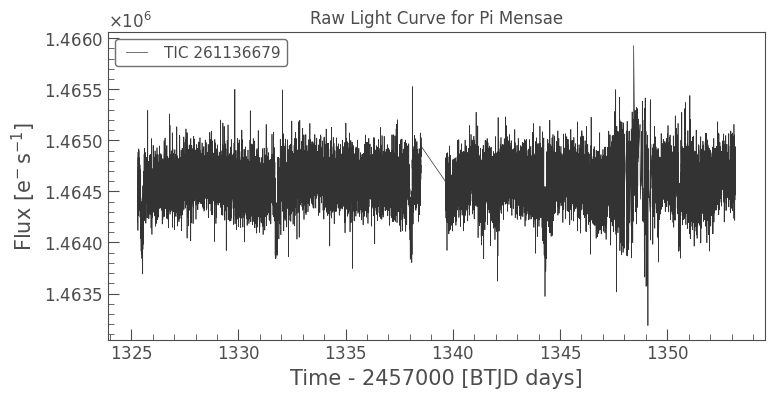

In [9]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np

search_result = lk.search_lightcurve("Pi Mensae", mission="TESS")

lc = search_result[0].download()

print(lc)

lc.plot()
plt.title("Raw Light Curve for Pi Mensae")
plt.show()

In [10]:
num_obs = len(lc.flux)

start_time = lc.time.value[0]
end_time = lc.time.value[-1]

total_duration = end_time - start_time

print(f"Number of observations: {num_obs}")
print(f"Start time (BTJD): {start_time:.2f}")
print(f"End time (BTJD): {end_time:.2f}")
print(f"Total observation duration (days): {total_duration:.2f}")

Number of observations: 18264
Start time (BTJD): 1325.30
End time (BTJD): 1353.18
Total observation duration (days): 27.88


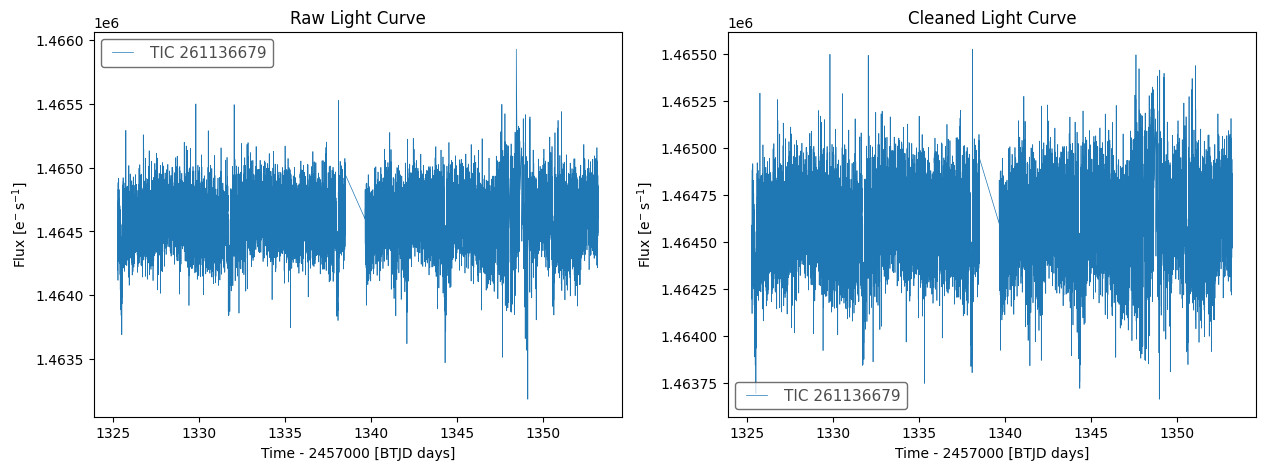

In [11]:
lc_clean = lc.remove_nans().remove_outliers()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

lc.plot(ax=axes[0])
axes[0].set_title("Raw Light Curve")

lc_clean.plot(ax=axes[1])
axes[1].set_title("Cleaned Light Curve")

plt.show()

In [12]:
flux_values = lc_clean.flux.value

mean_flux = np.mean(flux_values)
median_flux = np.median(flux_values)
std_flux = np.std(flux_values)
min_flux = np.min(flux_values)
max_flux = np.max(flux_values)

print(f"Mean flux: {mean_flux:.2f}")
print(f"Median flux: {median_flux:.2f}")
print(f"Standard deviation of flux: {std_flux:.2f}")
print(f"Minimum flux: {min_flux:.2f}")
print(f"Maximum flux: {max_flux:.2f}")

Mean flux: 1464594.62
Median flux: 1464602.38
Standard deviation of flux: 195.93
Minimum flux: 1463661.62
Maximum flux: 1465526.12


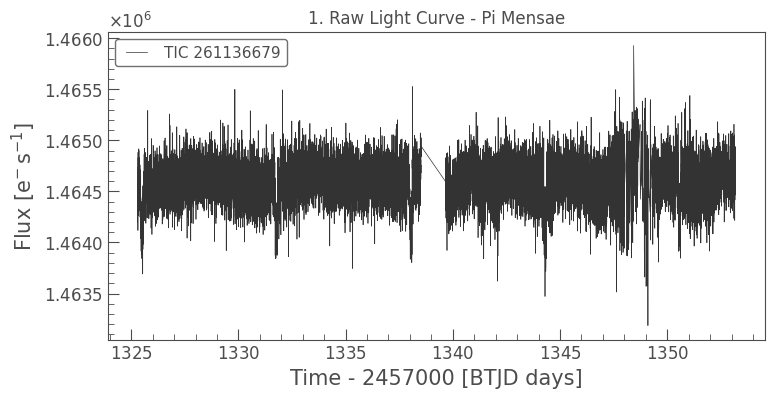

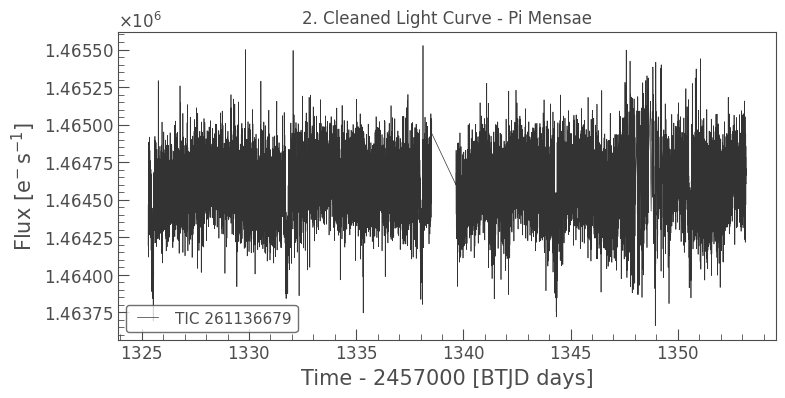

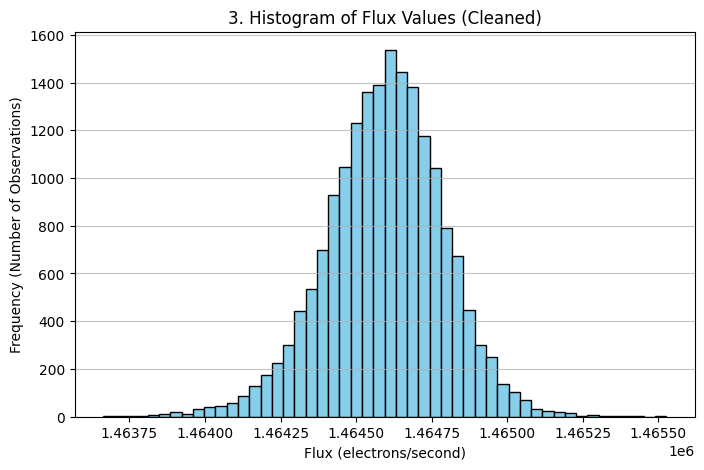

In [17]:
ax = lc.plot()
ax.set_title("1. Raw Light Curve - Pi Mensae")
plt.show()

ax_clean = lc_clean.plot()
ax_clean.set_title("2. Cleaned Light Curve - Pi Mensae")
plt.show()

plt.figure(figsize=(8, 5))
flux_data = np.asarray(lc_clean.flux.value.data).astype(np.float64)
plt.hist(flux_data, bins=50, color='skyblue', edgecolor='black')
plt.title("3. Histogram of Flux Values (Cleaned)")
plt.xlabel("Flux (electrons/second)")
plt.ylabel("Frequency (Number of Observations)")
plt.grid(axis='y', alpha=0.75)
plt.show()